In [60]:
# CONNECT TO DATABASE
import pandas as pd
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path

#Check env location 
env_path = Path('..') / '.env'
# Load environment variables from .env file
load_dotenv()

print(os.getenv("DB_HOST"));

# Correctly loaded environment variables
DB_HOST = os.getenv("DB_HOST")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

# Use f-string with actual variables
engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}"
)


try:
    with engine.connect() as connection:
        result = connection.execute(text("SELECT 1"))
        print("Connection successfully!")
except Exception as e:
    print("NO: Connection failed:")
    print(e)


localhost
Connection successfully!


Overall Price Index Stats:
count    3.626080e+06
mean     7.943730e+01
std      2.756353e+01
min      1.670000e+01
25%      5.450000e+01
50%      8.440000e+01
75%      9.990000e+01
max      2.124000e+02
Name: price_index, dtype: float64

Stats by Component:
                            count       mean        std   min   25%   50%  \
component                                                                   
House only              1208480.0  80.745733  29.009041  20.7  53.8  85.5   
Land only               1209120.0  77.738398  25.980709  16.7  54.1  83.2   
Total (house and land)  1208480.0  79.828655  27.532097  19.8  55.2  83.6   

                          75%    max  
component                             
House only              100.1  212.4  
Land only                99.8  162.0  
Total (house and land)   99.7  175.9  

Observations by Geography:
geo
Alberta                                                276480
Atlantic Region                                         23040
Briti

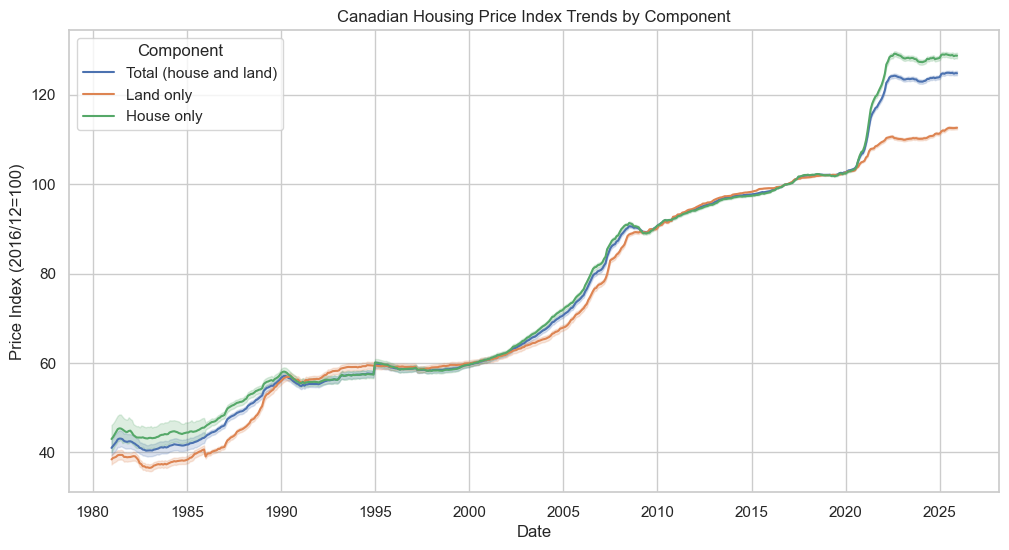

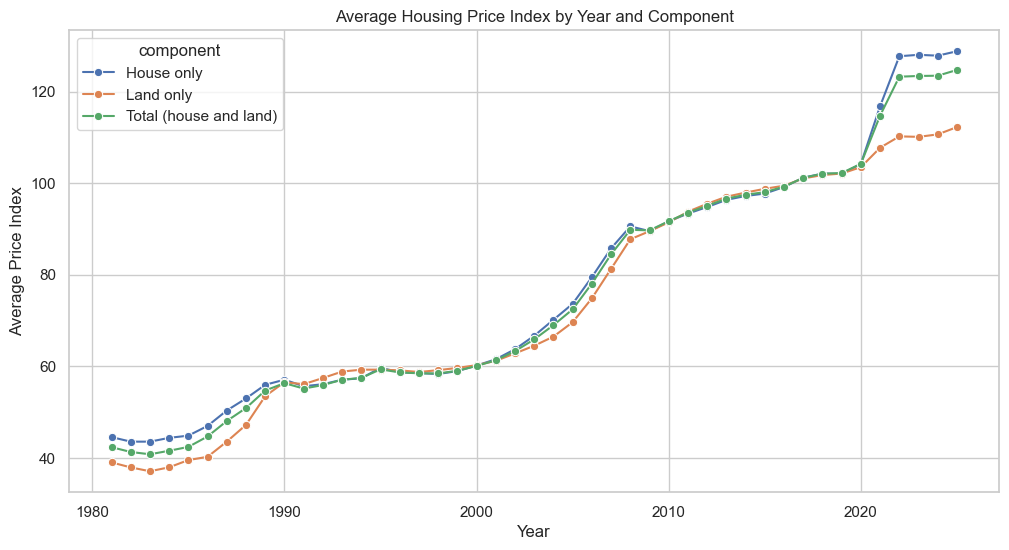

In [57]:
query = """
SELECT 
    h.price_index,
    d.full_date AS date,
    g.geo_name AS geo,
    gl.level_name AS geo_level,
    c.component_name AS component
FROM housing_price_index h
JOIN dates d ON h.date_id = d.date_id
JOIN geography g ON h.geo_id = g.geo_id
JOIN geographic_levels gl ON g.level_id = gl.level_id
JOIN components c ON h.component_id = c.component_id
"""
df = pd.read_sql(query, engine)

# Convert date to datetime and extract year
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

# -------------------------------
# Basic Descriptive Stats
# -------------------------------
print("Overall Price Index Stats:")
print(df["price_index"].describe())

print("\nStats by Component:")
print(df.groupby("component")["price_index"].describe())

print("\nObservations by Geography:")
print(df.groupby("geo")["price_index"].count())

# -------------------------------
# Trend Over Time (Line Plot)
# -------------------------------
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x="date", y="price_index", hue="component")
plt.title("Canadian Housing Price Index Trends by Component")
plt.xlabel("Date")
plt.ylabel("Price Index (2016/12=100)")
plt.legend(title="Component")
plt.show()


# -------------------------------
# Yearly Average Index by Component
# -------------------------------
yearly = df.groupby(["year","component"])["price_index"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=yearly, x="year", y="price_index", hue="component", marker="o")
plt.title("Average Housing Price Index by Year and Component")
plt.xlabel("Year")
plt.ylabel("Average Price Index")
plt.show()



                                          region  earliest_index  \
0                             Winnipeg, Manitoba           108.3   
1                                       Manitoba           108.3   
2                                 Québec, Quebec           108.4   
3  Ottawa-Gatineau, Ontario part, Ontario/Quebec           134.2   
4                                London, Ontario           112.1   
5                               Calgary, Alberta           107.7   
6                               Montréal, Quebec           125.9   
7                                         Quebec           120.4   
8                                    Nova Scotia           103.5   
9                           Halifax, Nova Scotia           103.5   

   latest_index  growth_pct  
0         160.4     48.1071  
1         160.4     48.1071  
2         152.8     40.9594  
3         186.0     38.5991  
4         154.9     38.1802  
5         144.3     33.9833  
6         168.4     33.7569  
7         1

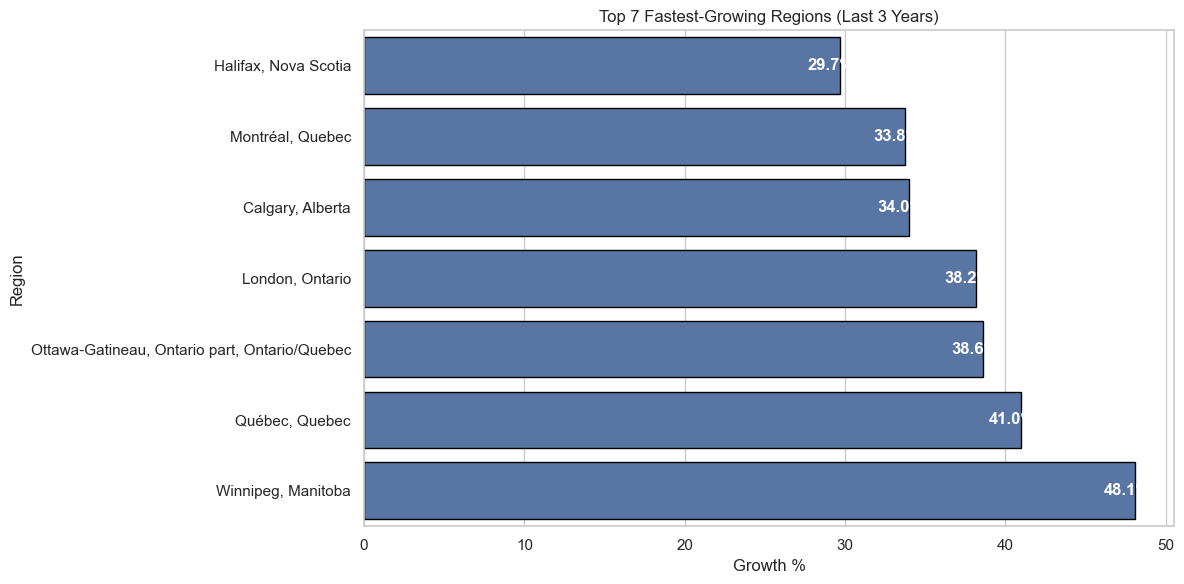

In [81]:
#-------------------------------
# Top 10 Regions by Latest Price Index
# -------------------------------
query_top_growth_3_years = """WITH last_3_years AS (
    SELECT 
        g.geo_name AS region,
        h.price_index,
        d.full_date AS date
    FROM housing_price_index h
    JOIN geography g ON h.geo_id = g.geo_id
    JOIN dates d ON h.date_id = d.date_id
    WHERE d.full_date >= DATE_SUB(CURRENT_DATE, INTERVAL 3 YEAR)
),
region_growth AS (
    SELECT 
        region,
        MIN(price_index) AS earliest_index,
        MAX(price_index) AS latest_index,
        ((MAX(price_index) - MIN(price_index)) / MIN(price_index)) * 100 AS growth_pct
    FROM last_3_years
    GROUP BY region
)
SELECT *
FROM region_growth
ORDER BY growth_pct DESC
LIMIT 10;
"""

df = pd.read_sql(query_top_growth_3_years, engine)
print(df)

# Sort top 10 by growth_pct (already limited in SQL, but safe)
# Keep only the most granular regions (exclude province-level duplicates)
# Keep only the most granular regions (exclude province-level duplicates)
top_regions_3y_clean = df[~df['region'].isin(['Manitoba', 'Quebec', 'Nova Scotia'])]

# Sort ascending for horizontal bar chart
top_regions_3y_clean = top_regions_3y_clean.sort_values("growth_pct", ascending=True)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_regions_3y_clean,
    x="growth_pct",
    y="region",
    color="#4C72b0",
    edgecolor="black"
)

plt.title("Top 7 Fastest-Growing Regions (Last 3 Years)")
plt.xlabel("Growth %")
plt.ylabel("Region")

# Add labels at the end of bars
for index, value in enumerate(top_regions_3y_clean["growth_pct"]):
    plt.text(value - 2, index, f"{value:.1f}%", va='center', color="white", fontweight="bold")

plt.tight_layout()
plt.show()


                                          region  earliest_index  \
0                             Winnipeg, Manitoba           108.3   
1                                       Manitoba           108.3   
2                                 Québec, Quebec           108.4   
3  Ottawa-Gatineau, Ontario part, Ontario/Quebec           134.2   
4                                London, Ontario           112.1   
5                               Calgary, Alberta           107.7   
6                               Montréal, Quebec           125.9   
7                                         Quebec           120.4   
8                                    Nova Scotia           103.5   
9                           Halifax, Nova Scotia           103.5   

   latest_index  growth_pct  
0         160.4     48.1071  
1         160.4     48.1071  
2         152.8     40.9594  
3         186.0     38.5991  
4         154.9     38.1802  
5         144.3     33.9833  
6         168.4     33.7569  
7         1

/var/folders/ln/bqrb78gn6zn6zts3yvyxtlcc0000gn/T/ipykernel_44767/215921888.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_prov, x="growth_pct", y="province", palette="Set2")


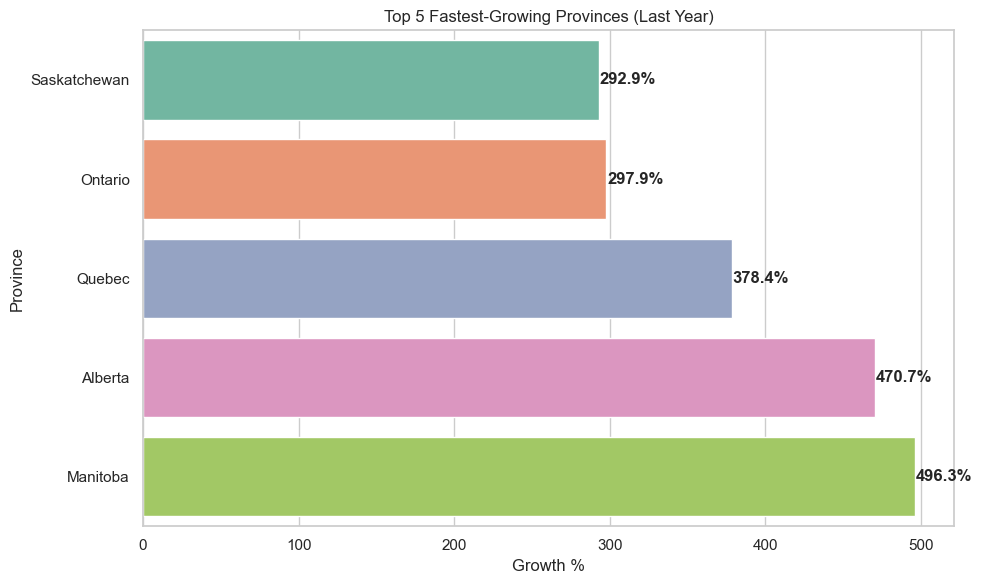

Exception during reset or similar
Traceback (most recent call last):
  File "/Users/kaitimokrong/Desktop/Canada Housing Data Project/venv/lib/python3.9/site-packages/sqlalchemy/pool/base.py", line 985, in _finalize_fairy
    fairy._reset(
  File "/Users/kaitimokrong/Desktop/Canada Housing Data Project/venv/lib/python3.9/site-packages/sqlalchemy/pool/base.py", line 1433, in _reset
    pool._dialect.do_rollback(self)
  File "/Users/kaitimokrong/Desktop/Canada Housing Data Project/venv/lib/python3.9/site-packages/sqlalchemy/engine/default.py", line 712, in do_rollback
    dbapi_connection.rollback()
  File "/Users/kaitimokrong/Desktop/Canada Housing Data Project/venv/lib/python3.9/site-packages/mysql/connector/connection_cext.py", line 611, in rollback
    self._cmysql.rollback()
_mysql_connector.MySQLInterfaceError: Commands out of sync; you can't run this command now
Exception during reset or similar
Traceback (most recent call last):
  File "/Users/kaitimokrong/Desktop/Canada Housing D

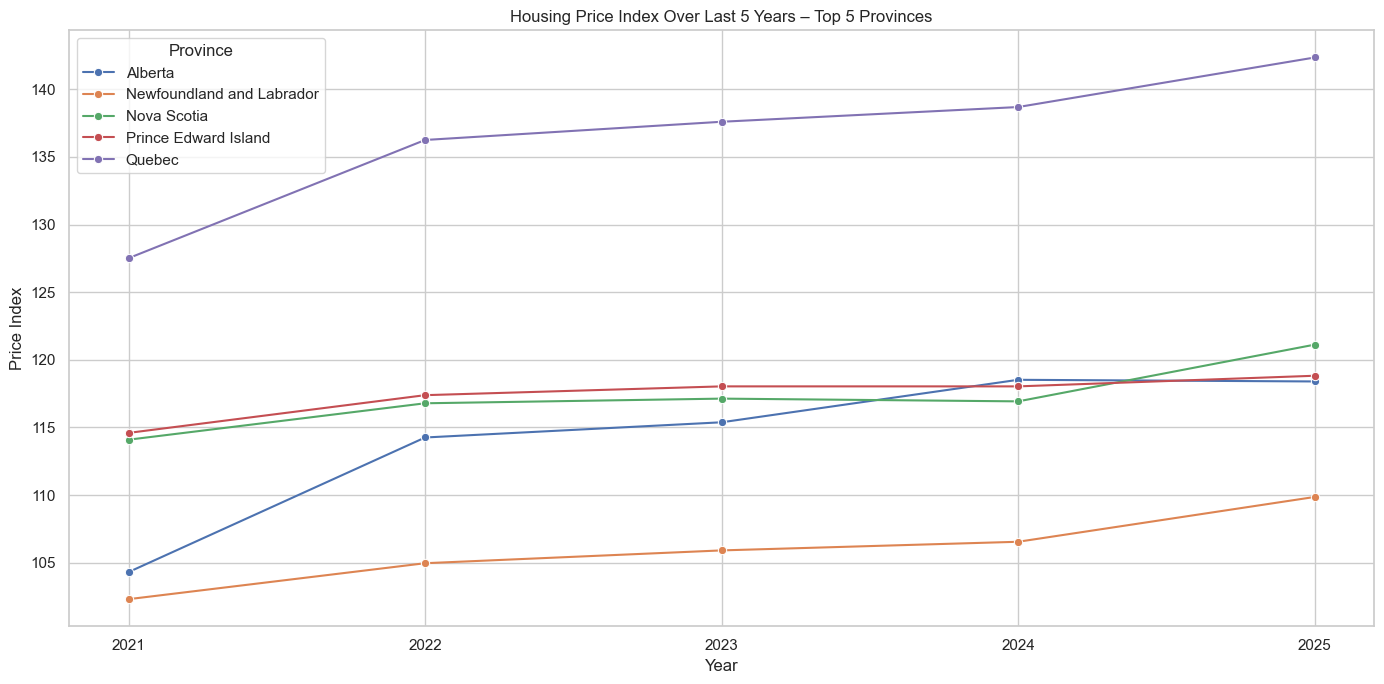

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# SQL query for top 5 fastest-growing provinces
# -------------------------------
query_fastest_growing_province = """
WITH province_latest AS (
    SELECT 
        g.geo_name AS province,
        h.price_index,
        d.full_date AS date
    FROM housing_price_index h
    JOIN geography g ON h.geo_id = g.geo_id
    JOIN geographic_levels gl ON g.level_id = gl.level_id
    JOIN dates d ON h.date_id = d.date_id
    WHERE gl.level_name = 'Province'
),
province_growth AS (
    SELECT 
        province,
        MIN(price_index) AS earliest_index,
        MAX(price_index) AS latest_index,
        ((MAX(price_index) - MIN(price_index)) / MIN(price_index)) * 100 AS growth_pct
    FROM province_latest
    GROUP BY province
)
SELECT *
FROM province_growth
ORDER BY growth_pct DESC
LIMIT 5;
"""

# -------------------------------
# Run the query using your DB engine
# -------------------------------
df_prov = pd.read_sql(query_fastest_growing_province, engine)
print(df)

# Optional: sort for plotting
# Sort for plotting (ascending so smallest growth on top)
df_prov = df_prov.sort_values("growth_pct", ascending=True).reset_index(drop=True)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=df_prov, x="growth_pct", y="province", palette="Set2")

# Add labels at the end of bars
for i, (growth, province) in enumerate(zip(df_prov["growth_pct"], df_prov["province"])):
    ax.text(growth + 0.5, i, f"{growth:.1f}%", va='center', fontweight="bold")

plt.title("Top 5 Fastest-Growing Provinces (Last Year)")
plt.xlabel("Growth %")
plt.ylabel("Province")
plt.tight_layout()
plt.show()



##########

query_last5y = """
SELECT 
    g.geo_name AS province,
    h.price_index,
    d.full_date AS date
FROM housing_price_index h
JOIN geography g ON h.geo_id = g.geo_id
JOIN geographic_levels gl ON g.level_id = gl.level_id
JOIN dates d ON h.date_id = d.date_id
WHERE gl.level_name = 'Province'
  AND d.full_date >= DATE_SUB(CURRENT_DATE, INTERVAL 5 YEAR)
ORDER BY g.geo_name, d.full_date;
"""

# Use a fresh connection
with engine.connect() as conn:
    df_5y = pd.read_sql(query_last5y, conn)

# Ensure date column is datetime
df_5y["date"] = pd.to_datetime(df_5y["date"])

# Compute total growth over 5 years
province_growth = (
    df_5y.groupby("province")
        .agg(earliest_index=("price_index","first"),
             latest_index=("price_index","last"))
        .assign(growth_pct=lambda x: (x.latest_index - x.earliest_index)/x.earliest_index*100)
        .sort_values("growth_pct", ascending=False)
)

# Top 5 provinces
top5_provinces = province_growth.head(5).index.tolist()
df_top5 = df_5y[df_5y["province"].isin(top5_provinces)].copy()

# Aggregate by year for smoother lines
df_top5["year"] = df_top5["date"].dt.year
df_top5_time = df_top5.groupby(["province","year"]).agg({"price_index":"mean"}).reset_index()

# Plot
plt.figure(figsize=(14,7))
sns.set_style("whitegrid")
sns.lineplot(data=df_top5_time, x="year", y="price_index", hue="province", marker="o")

plt.title("Housing Price Index Over Last 5 Years – Top 5 Provinces")
plt.xlabel("Year")
plt.ylabel("Price Index")
plt.legend(title="Province")
plt.xticks(df_top5_time["year"].unique())
plt.tight_layout()
plt.show()




Connection successfully!
Index(['price_index', 'date', 'geo', 'geo_level', 'component'], dtype='object')


/var/folders/ln/bqrb78gn6zn6zts3yvyxtlcc0000gn/T/ipykernel_44767/860911216.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total['date_str'] = df_total['date'].dt.strftime('%Y-%m')


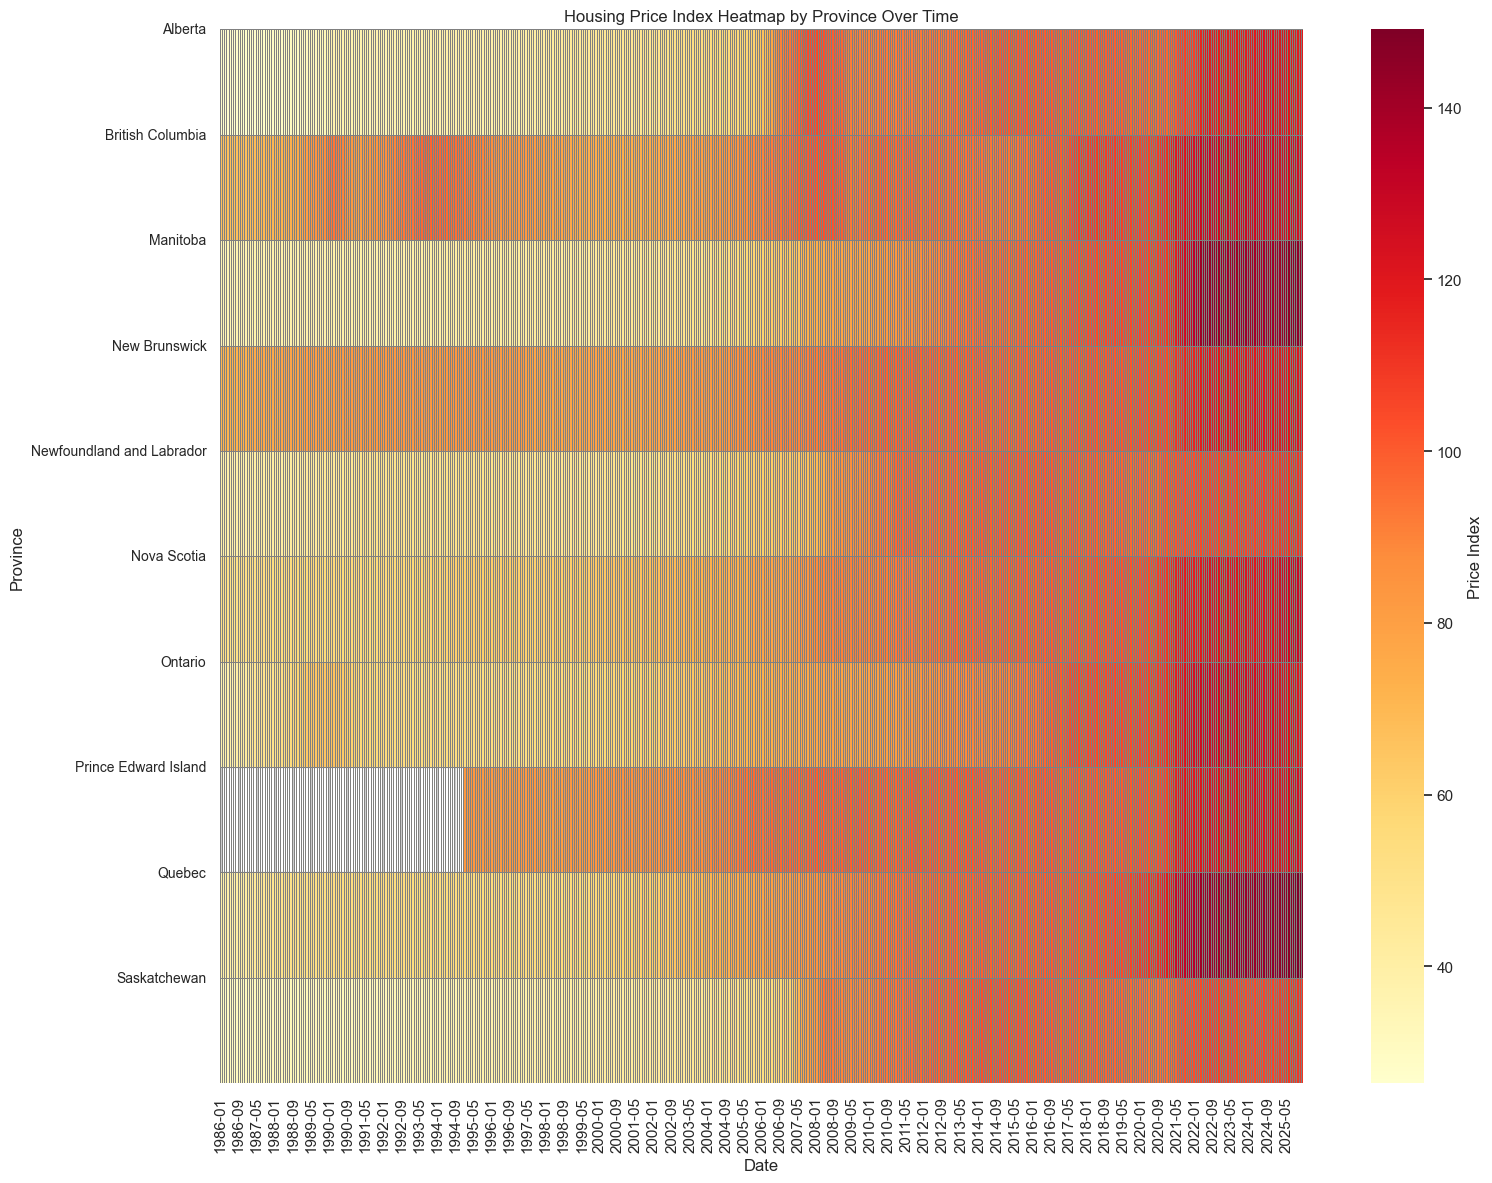


 AVG price index by Cities
                                                 city  avg_price_index
0                                     Guelph, Ontario           114.03
1                           Kelowna, British Columbia           112.75
2                                     Oshawa, Ontario           112.38
3        Ottawa-Gatineau, Quebec part, Ontario/Quebec           108.77
4                              Trois-Rivières, Quebec           106.51
5                                  Sherbrooke, Quebec           105.52
6                          Victoria, British Columbia           103.89
7                 Charlottetown, Prince Edward Island            95.50
8                                Prince Edward Island            95.50
9                                    British Columbia            93.64
10                                   Windsor, Ontario            92.44
11                        Vancouver, British Columbia            90.63
12                                      New Bruns

/var/folders/ln/bqrb78gn6zn6zts3yvyxtlcc0000gn/T/ipykernel_44767/860911216.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_avg,


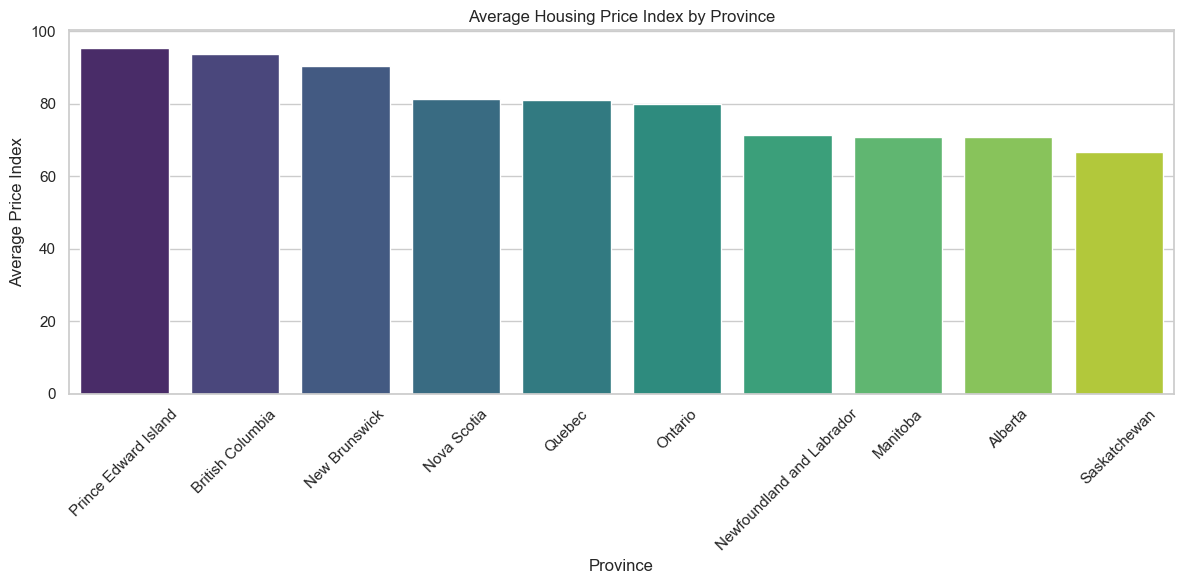

/var/folders/ln/bqrb78gn6zn6zts3yvyxtlcc0000gn/T/ipykernel_44767/860911216.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


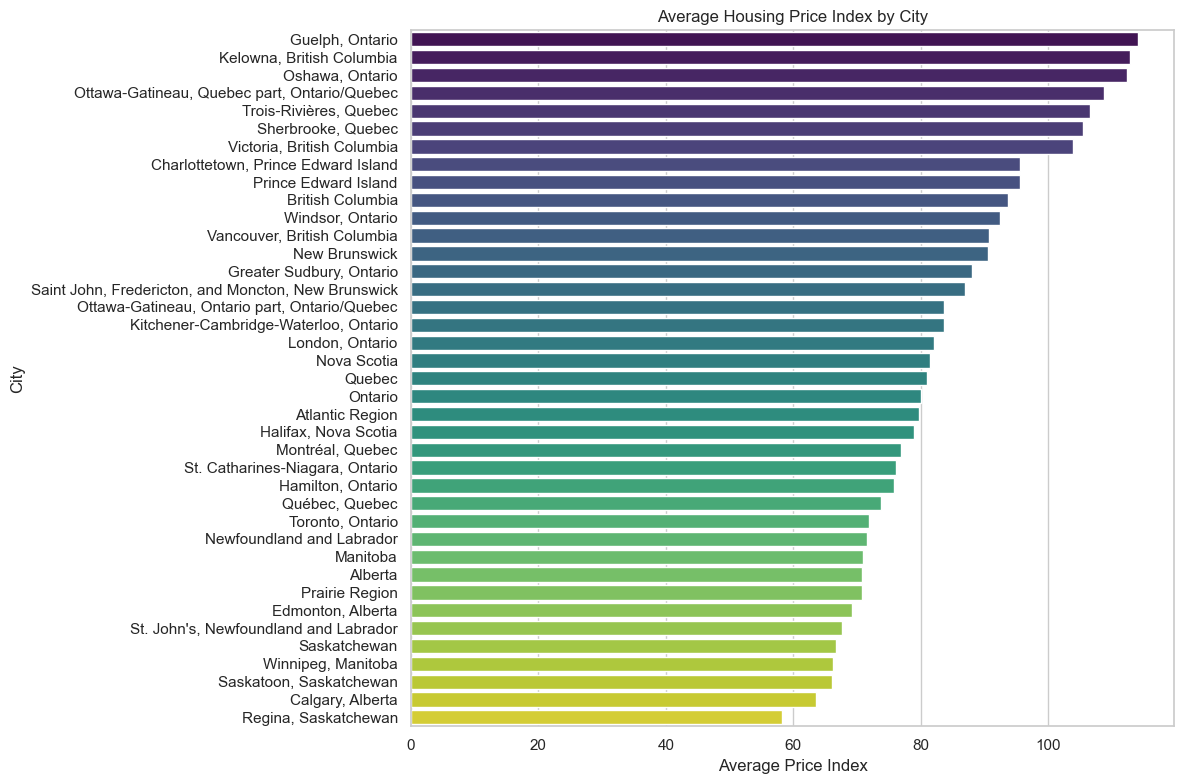

   full_date province  avg_price_index
0 1986-01-01  Alberta        25.633333
1 1986-02-01  Alberta        25.933333
2 1986-03-01  Alberta        26.100000
3 1986-04-01  Alberta        26.066667
4 1986-05-01  Alberta        26.100000


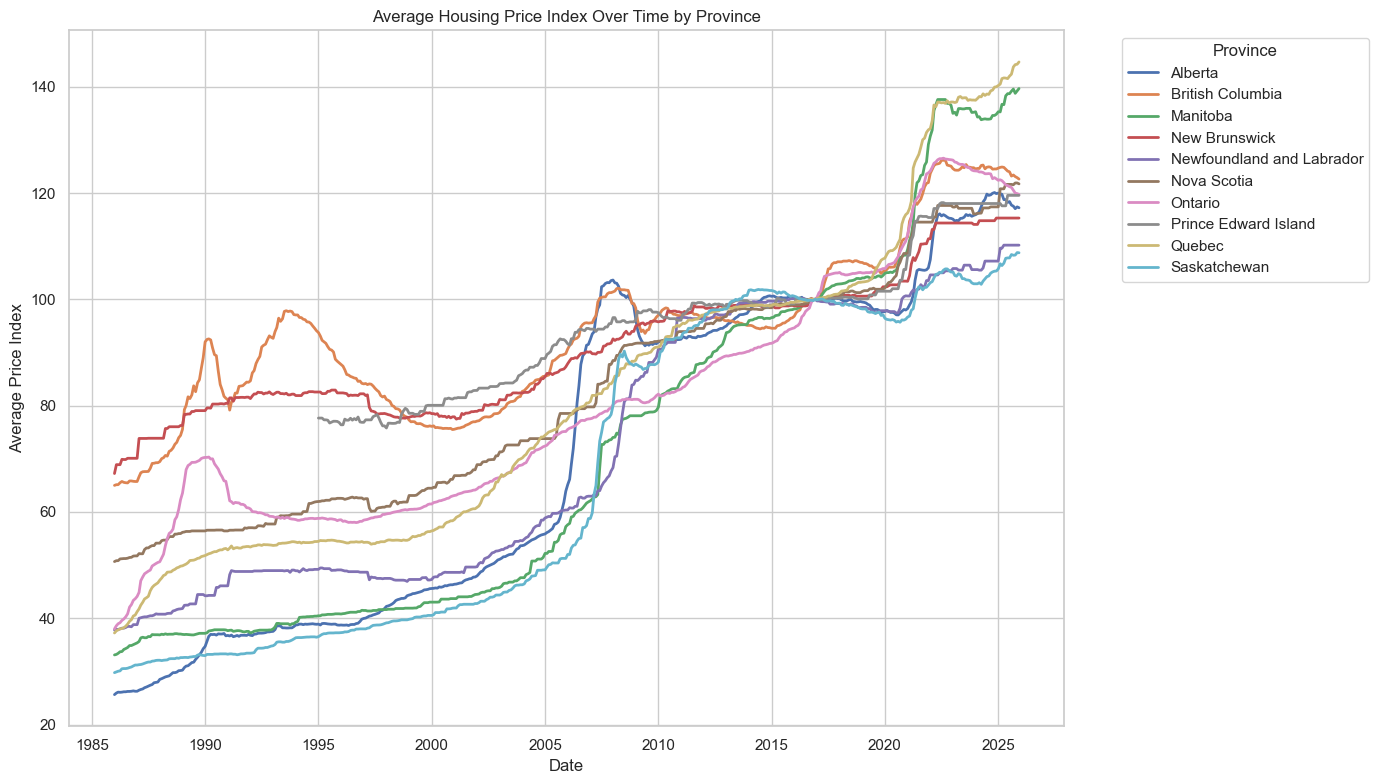

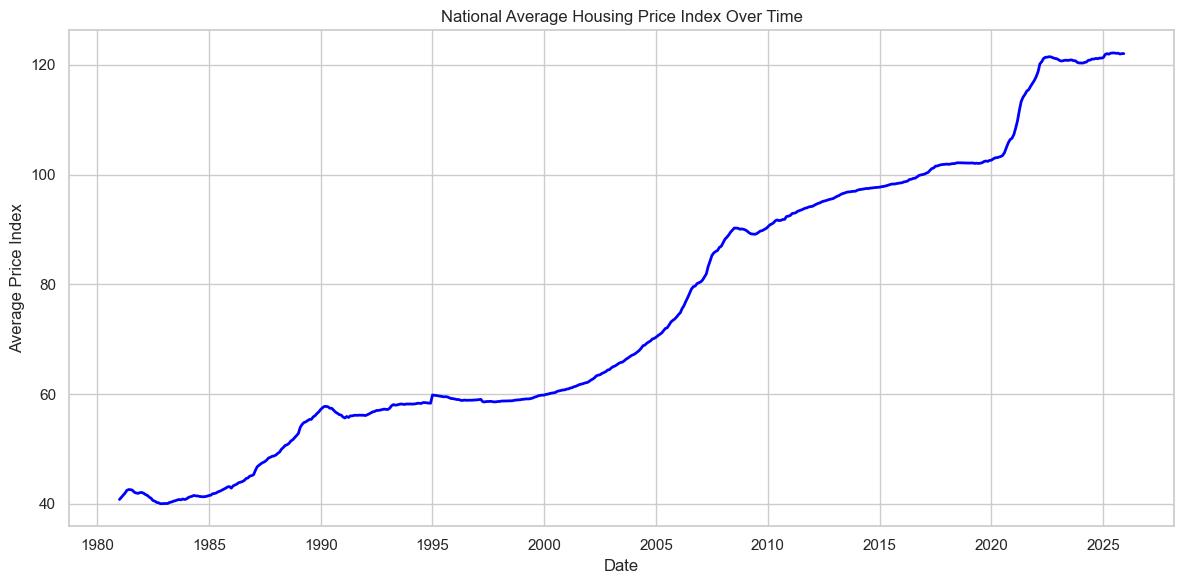

In [ ]:
try:
    with engine.connect() as connection:
        result = connection.execute(text("SELECT 1"))
        print("Connection successfully!")
except Exception as e:
    print("NO: Connection failed:")
    print(e)


# -------------------------------
# Pull data directly from SQL
# -------------------------------
query2 = """
SELECT 
    h.price_index,
    d.full_date AS date,
    g.geo_name AS geo,
    gl.level_name AS geo_level,
    c.component_name AS component
FROM housing_price_index h
JOIN dates d ON h.date_id = d.date_id
JOIN geography g ON h.geo_id = g.geo_id
JOIN geographic_levels gl ON g.level_id = gl.level_id
JOIN components c ON h.component_id = c.component_id
WHERE gl.level_name = 'Province'  -- only provinces
"""

## 2nd one NEW 
df_heat = pd.read_sql(query2, engine)
print(df_heat.columns)
# Use only "Total (house and land)" component
df_heat['date'] = pd.to_datetime(df_heat['date'])
df_total = df_heat[df_heat['component'] == 'Total (house and land)']

# CHANGE FORMAT of DATE
# Format as "YYYY-MM" (year + month) for better readability
df_total['date_str'] = df_total['date'].dt.strftime('%Y-%m')


# Pivot table
heatmap_data = df_total.pivot_table(
    index='geo',
    columns='date_str',
    values='price_index',
    aggfunc='mean'  # or np.mean
)



#OPTION 2 ROTATE IT 
plt.figure(figsize=(16,12))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.5, linecolor='gray', cbar_kws={'label':'Price Index'})

# Rotate labels and increase spacing
plt.yticks(ticks=range(len(heatmap_data.index)), labels=heatmap_data.index, rotation=0, fontsize=10)

plt.title("Housing Price Index Heatmap by Province Over Time")
plt.xlabel("Date")
plt.ylabel("Province")
plt.tight_layout()
plt.show()



# -------------------------------
# Average Price Index per CITY 
# ----------------------------
avg_price_index_city_query = """
SELECT
    g.geo_name AS city,
    ROUND(AVG(h.price_index), 2) AS avg_price_index
FROM housing_price_index h
JOIN geography g ON h.geo_id = g.geo_id
WHERE g.level_id = 1
  AND g.geo_name != 'Canada' 
GROUP BY g.geo_name
ORDER BY avg_price_index DESC;
"""

# -------------------------------
# Average Price Index per Province
# -------------------------------
avg_price_index_province_query = """
SELECT 
    g.geo_name AS province,
    ROUND(AVG(h.price_index), 2) AS avg_price_index
FROM housing_price_index h
JOIN geography g ON h.geo_id = g.geo_id
JOIN geographic_levels gl ON g.level_id = gl.level_id
WHERE gl.level_name = 'Province'
GROUP BY g.geo_name
ORDER BY avg_price_index DESC;
"""
df_avg = pd.read_sql(avg_price_index_province_query, engine)

df_avgCity = pd.read_sql(avg_price_index_city_query, engine)
print('\n AVG price index by Cities')
print(df_avgCity)

print("\nAverage Price Index by Province:")
print(df_avg)

# -------------------------------
# Plot Average Price Index
# -------------------------------

plt.figure(figsize=(12,6))
sns.barplot(data=df_avg, 
            x="province", 
            y="avg_price_index",
            palette="viridis")

plt.xticks(rotation=45)
plt.title("Average Housing Price Index by Province")
plt.xlabel("Province")
plt.ylabel("Average Price Index")
plt.tight_layout()
plt.show()

# PLOT AVG CITY INDEX 
plt.figure(figsize=(12,8))
sns.barplot(
    data=df_avgCity,
    y="city",            # city names on y-axis
    x="avg_price_index", # values on x-axis
    palette="viridis"
)

plt.xlabel("Average Price Index")
plt.ylabel("City")
plt.title("Average Housing Price Index by City")
plt.tight_layout()  # auto-adjust spacing
plt.show()




# trend by province over time
# 
# SELECT d.full_date,
# -------------------------------
# Time Series: Avg Price Index per Province
# Includes date (d.full_date) → calculates average per province per date.
#Groups by province + date.
# Result: multiple rows per province, one for each date.

#Ideal for a time-series line chart, showing trends over time.
# -------------------------------

time_series_query = """
SELECT d.full_date,
       g.geo_name AS province,
       AVG(h.price_index) AS avg_price_index
FROM housing_price_index h
JOIN dates d ON h.date_id = d.date_id
JOIN geography g ON h.geo_id = g.geo_id
WHERE g.level_id = 3  -- provinces
GROUP BY d.full_date, g.geo_name
ORDER BY g.geo_name, d.full_date;
"""

df_time = pd.read_sql(time_series_query, engine)

# Convert date column to datetime
df_time['full_date'] = pd.to_datetime(df_time['full_date'])

print(df_time.head())

plt.figure(figsize=(14,8))

sns.lineplot(
    data=df_time,
    x="full_date",
    y="avg_price_index",
    hue="province",
    linewidth=2
)

plt.title("Average Housing Price Index Over Time by Province")
plt.xlabel("Date")
plt.ylabel("Average Price Index")
plt.legend(title="Province", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# LAST ONE /*Trend of housing price index over time (national)*/
country_query = """
SELECT d.full_date,
       AVG(h.price_index) AS avg_price_index
FROM housing_price_index h
JOIN dates d ON h.date_id = d.date_id
JOIN geography g ON h.geo_id = g.geo_id
WHERE g.level_id = 1
GROUP BY d.full_date
ORDER BY d.full_date;
"""

df_country = pd.read_sql(country_query, engine)
df_country['full_date'] = pd.to_datetime(df_country['full_date'])

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(data=df_country, x='full_date', y='avg_price_index', color='blue', linewidth=2)
plt.title("National Average Housing Price Index Over Time")
plt.xlabel("Date")
plt.ylabel("Average Price Index")
plt.tight_layout()
plt.show()


Index(['region', 'latest_index', 'latest_date', 'level_name'], dtype='object')
                                  region  latest_index latest_date level_name
0                      Edmonton, Alberta         105.0  2025-12-01    Country
1                   Regina, Saskatchewan         107.6  2025-12-01    Country
2                      Hamilton, Ontario         110.3  2025-12-01    Country
3  St. John's, Newfoundland and Labrador         111.0  2025-12-01    Country
4              Newfoundland and Labrador         111.0  2025-12-01   Province


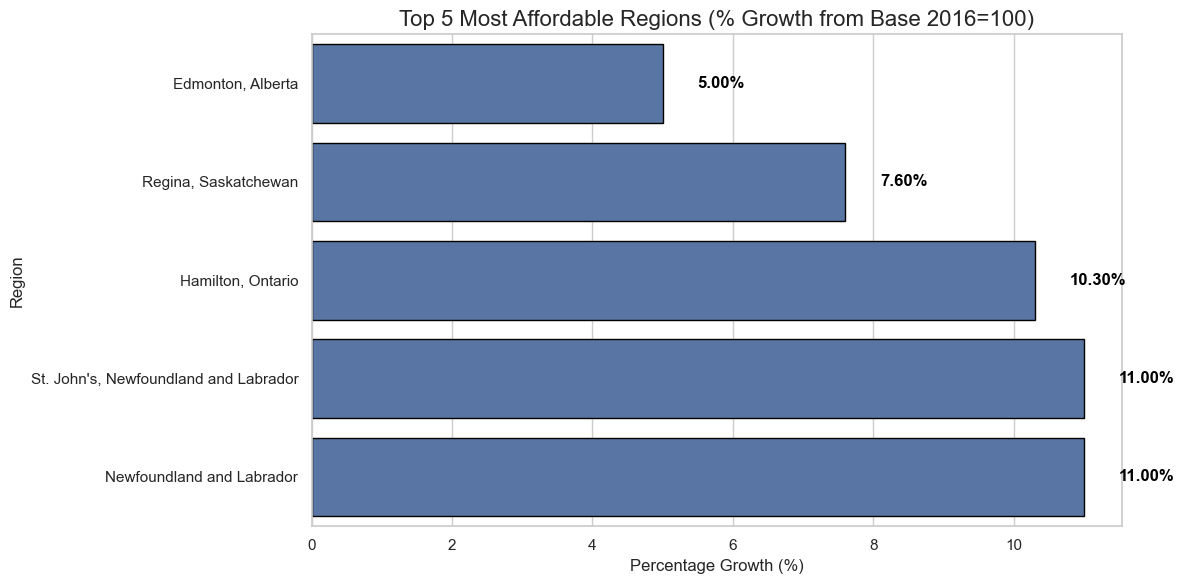

In [86]:
query_top_5_least_growth= """WITH latest_data AS (
    SELECT 
        g.geo_name AS region,
        MAX(h.price_index) AS latest_index,
        d.full_date AS latest_date,
        gl.level_name
    FROM housing_price_index h
    JOIN geography g ON h.geo_id = g.geo_id
    JOIN geographic_levels gl ON g.level_id = gl.level_id
    JOIN dates d ON h.date_id = d.date_id
    WHERE d.full_date = (SELECT MAX(full_date) FROM dates)
    GROUP BY g.geo_name, gl.level_name, d.full_date
)
SELECT *
FROM latest_data
ORDER BY latest_index ASC
LIMIT 5;
"""

df_latest = pd.read_sql(query_top_5_least_growth, engine)
print(df_latest.columns)


# Remove duplicates
df_latest_unique = df_latest.drop_duplicates(subset=['region', 'level_name'])

# Top 5 affordable regions
top5_affordable = df_latest_unique.sort_values('latest_index', ascending=True).head(5)
print(top5_affordable[['region', 'latest_index', 'latest_date', 'level_name']])

# Ensure we are using the latest data
import matplotlib.pyplot as plt
import seaborn as sns

# Sort top 5 most affordable regions

# Calculate percentage growth from base index = 100
top5_affordable['growth_pct'] = (top5_affordable['latest_index'] - 100) / 100 * 100

# Sort ascending → most affordable (lowest % growth) on top
top5_affordable = top5_affordable.sort_values('growth_pct', ascending=True).head(5)

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

# Horizontal bar chart
sns.barplot(
    data=top5_affordable,
    x='growth_pct',
    y='region',
    color="#4C72B0",
    edgecolor='black'
)

plt.title("Top 5 Most Affordable Regions (% Growth from Base 2016=100)", fontsize=16)
plt.xlabel("Percentage Growth (%)", fontsize=12)
plt.ylabel("Region", fontsize=12)

# Add labels at the end of bars
for i, value in enumerate(top5_affordable['growth_pct']):
    plt.text(value + 0.5, i, f"{value:.2f}%", va='center', color="black", fontweight="bold")

plt.tight_layout()
plt.show()
